In [7]:
!pip install -r requirements.txt

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.2 MB/s  0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("input/student_mcq.csv", sep=",")
df.head()

,Unnamed: 0,Unnamed: 1,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,1101901107,Suy chakriya,D,C,B,A,B,B,B,D,D,D,B,C,B,C,B,C,B,C,B,C
1,1101901111,Ung Keng long,A,A,A,A,B,C,A,C,C,B,B,C,B,C,A,C,A,C,B,C
2,1101901114,Yin Chantha,D,A,D,C,B,D,A,A,C,B,B,C,B,C,D,C,A,C,A,D
3,1101901109,Thy Saonan,B,A,A,A,B,C,A,C,A,B,B,C,B,C,B,C,A,C,B,B
4,1101901108,Thorn Theanlay,A,D,A,C,C,B,B,C,C,B,B,C,B,C,D,C,A,C,B,C


In [3]:
answers = np.array(['B', 'C', 'A', 'C', 'B', 'A', 'A', 'C', 'A', 'B', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'C', 'B', 'B'])

In [4]:
df.drop(columns=["Unnamed: 0", "Unnamed: 1"], inplace=True)
df.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,D,C,B,A,B,B,B,D,D,D,B,C,B,C,B,C,B,C,B,C
1,A,A,A,A,B,C,A,C,C,B,B,C,B,C,A,C,A,C,B,C
2,D,A,D,C,B,D,A,A,C,B,B,C,B,C,D,C,A,C,A,D
3,B,A,A,A,B,C,A,C,A,B,B,C,B,C,B,C,A,C,B,B
4,A,D,A,C,C,B,B,C,C,B,B,C,B,C,D,C,A,C,B,C


In [5]:
df = (df == answers).astype(int)
df.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0,1,0,0,1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0
1,0,0,1,0,1,0,1,1,0,1,1,1,1,1,0,1,0,1,1,0
2,0,0,0,1,1,0,1,0,0,1,1,1,1,1,0,1,0,1,0,0
3,1,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1
4,0,0,1,1,0,0,0,1,0,1,1,1,1,1,0,1,0,1,1,0


In [6]:
question_summary = pd.DataFrame({
    "correct_rate": df.mean(),
    "incorrect_rate": 1 - df.mean(),
    "n_correct": df.sum(),
    "n_incorrect": len(df) - df.sum()
}).sort_values("correct_rate")

question_summary

,correct_rate,incorrect_rate,n_correct,n_incorrect
1,0.12,0.88,6,44
20,0.22,0.78,11,39
9,0.26,0.74,13,37
6,0.26,0.74,13,37
17,0.32,0.68,16,34
3,0.38,0.62,19,31
5,0.40,0.60,20,30
7,0.42,0.58,21,29
4,0.44,0.56,22,28
15,0.48,0.52,24,26


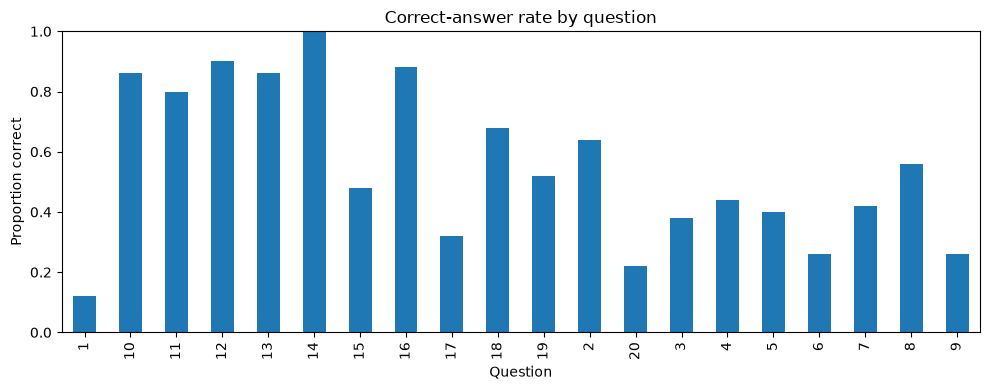

In [7]:
ax = question_summary["correct_rate"].sort_index().plot(
    kind="bar",
    figsize=(10, 4)
)
ax.set_title("Correct-answer rate by question")
ax.set_xlabel("Question")
ax.set_ylabel("Proportion correct")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
def row_to_transaction(row):
    transaction = []
    for question, value in row.items():
        status = "correct" if value == 1 else "incorrect"
        transaction.append(f"{question}_{status}")
    return transaction

transactions = df.apply(row_to_transaction, axis=1).tolist()

# Display the first three transactions.
transactions[:3]

[['1_incorrect',
  '2_correct',
  '3_incorrect',
  '4_incorrect',
  '5_correct',
  '6_incorrect',
  '7_incorrect',
  '8_incorrect',
  '9_incorrect',
  '10_incorrect',
  '11_correct',
  '12_correct',
  '13_correct',
  '14_correct',
  '15_correct',
  '16_correct',
  '17_correct',
  '18_correct',
  '19_correct',
  '20_incorrect'],
 ['1_incorrect',
  '2_incorrect',
  '3_correct',
  '4_incorrect',
  '5_correct',
  '6_incorrect',
  '7_correct',
  '8_correct',
  '9_incorrect',
  '10_correct',
  '11_correct',
  '12_correct',
  '13_correct',
  '14_correct',
  '15_incorrect',
  '16_correct',
  '17_incorrect',
  '18_correct',
  '19_correct',
  '20_incorrect'],
 ['1_incorrect',
  '2_incorrect',
  '3_incorrect',
  '4_correct',
  '5_correct',
  '6_incorrect',
  '7_correct',
  '8_incorrect',
  '9_incorrect',
  '10_correct',
  '11_correct',
  '12_correct',
  '13_correct',
  '14_correct',
  '15_incorrect',
  '16_correct',
  '17_incorrect',
  '18_correct',
  '19_incorrect',
  '20_incorrect']]

In [9]:
te = TransactionEncoder()
encoded = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded,
    columns=te.columns_,
    index=df.index
)

basket.head()

,10_correct,10_incorrect,11_correct,11_incorrect,12_correct,12_incorrect,13_correct,13_incorrect,14_correct,15_correct,15_incorrect,16_correct,16_incorrect,17_correct,17_incorrect,18_correct,18_incorrect,19_correct,19_incorrect,1_correct,1_incorrect,20_correct,20_incorrect,2_correct,2_incorrect,3_correct,3_incorrect,4_correct,4_incorrect,5_correct,5_incorrect,6_correct,6_incorrect,7_correct,7_incorrect,8_correct,8_incorrect,9_correct,9_incorrect
0,False,True,True,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False,False,True,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True
1,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,True,False,True,False,False,True,False,True,False,True,True,False,False,True,True,False,False,True,True,False,True,False,False,True
2,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,True,False,False,True,False,True,False,True,False,True,False,True,True,False,True,False,False,True,True,False,False,True,False,True
3,True,False,True,False,True,False,True,False,True,True,False,True,False,False,True,True,False,True,False,True,False,True,False,False,True,True,False,False,True,True,False,False,True,True,False,True,False,True,False
4,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,True,False,True,False,False,True,False,True,False,True,True,False,True,False,False,True,False,True,False,True,True,False,False,True


In [10]:
MIN_SUPPORT = 0.15

frequent_itemsets = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(
    ["length", "support"],
    ascending=[True, False]
)

frequent_itemsets.head(20)

,support,itemsets,length
5,1.00,frozenset({14_correct}),1
3,0.90,frozenset({12_correct}),1
8,0.88,frozenset({16_correct}),1
15,0.88,frozenset({1_incorrect}),1
0,0.86,frozenset({10_correct}),1
4,0.86,frozenset({13_correct}),1
1,0.80,frozenset({11_correct}),1
17,0.78,frozenset({20_incorrect}),1
27,0.74,frozenset({6_incorrect}),1
33,0.74,frozenset({9_incorrect}),1


In [11]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.60
)

# Keep useful columns and sort strongest rules near the top.
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    ["lift", "confidence", "support"],
    ascending=False
)

rules.head(20)

c:\Users\julia\SY2627\Projects\association_rule_mining_on_student_test\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift
6981,frozenset({20_correct}),"frozenset({6_incorrect, 15_correct})",0.18,0.818182,2.153110
7536,frozenset({20_correct}),"frozenset({15_correct, 18_correct})",0.16,0.727273,2.139037
7546,frozenset({20_correct}),"frozenset({15_correct, 9_incorrect})",0.16,0.727273,2.139037
6242,frozenset({20_correct}),"frozenset({11_correct, 15_correct})",0.20,0.909091,2.066116
6271,"frozenset({11_correct, 18_incorrect})",frozenset({8_incorrect}),0.20,0.909091,2.066116
6725,frozenset({20_correct}),"frozenset({10_correct, 15_correct})",0.18,0.818182,2.045455
7375,frozenset({11_incorrect}),"frozenset({9_incorrect, 15_incorrect})",0.16,0.800000,2.000000
6316,frozenset({20_correct}),"frozenset({12_correct, 15_correct})",0.20,0.909091,1.976285
6364,frozenset({20_correct}),"frozenset({13_correct, 15_correct})",0.20,0.909091,1.976285
6952,frozenset({20_correct}),"frozenset({15_correct, 16_correct})",0.18,0.818182,1.948052


In [12]:
def question_name(item):
    return item.rsplit("_", 1)[0]

def uses_distinct_questions(row):
    antecedent_questions = {question_name(x) for x in row["antecedents"]}
    consequent_questions = {question_name(x) for x in row["consequents"]}
    return antecedent_questions.isdisjoint(consequent_questions)

rules_distinct = rules[
    rules.apply(uses_distinct_questions, axis=1)
].copy()

rules_distinct.head(20)

,antecedents,consequents,support,confidence,lift
6981,frozenset({20_correct}),"frozenset({6_incorrect, 15_correct})",0.18,0.818182,2.153110
7536,frozenset({20_correct}),"frozenset({15_correct, 18_correct})",0.16,0.727273,2.139037
7546,frozenset({20_correct}),"frozenset({15_correct, 9_incorrect})",0.16,0.727273,2.139037
6242,frozenset({20_correct}),"frozenset({11_correct, 15_correct})",0.20,0.909091,2.066116
6271,"frozenset({11_correct, 18_incorrect})",frozenset({8_incorrect}),0.20,0.909091,2.066116
6725,frozenset({20_correct}),"frozenset({10_correct, 15_correct})",0.18,0.818182,2.045455
7375,frozenset({11_incorrect}),"frozenset({9_incorrect, 15_incorrect})",0.16,0.800000,2.000000
6316,frozenset({20_correct}),"frozenset({12_correct, 15_correct})",0.20,0.909091,1.976285
6364,frozenset({20_correct}),"frozenset({13_correct, 15_correct})",0.20,0.909091,1.976285
6952,frozenset({20_correct}),"frozenset({15_correct, 16_correct})",0.18,0.818182,1.948052


In [13]:
def all_incorrect(itemset):
    return all(item.endswith("_incorrect") for item in itemset)

incorrect_rules = rules_distinct[
    rules_distinct["antecedents"].apply(all_incorrect)
    & rules_distinct["consequents"].apply(all_incorrect)
].copy()

incorrect_rules.head(20)

,antecedents,consequents,support,confidence,lift
7375,frozenset({11_incorrect}),"frozenset({9_incorrect, 15_incorrect})",0.16,0.800000,2.000000
7713,"frozenset({19_incorrect, 4_incorrect})",frozenset({18_incorrect}),0.16,0.615385,1.923077
6061,frozenset({18_incorrect}),"frozenset({19_incorrect, 20_incorrect})",0.22,0.687500,1.909722
6058,"frozenset({19_incorrect, 20_incorrect})",frozenset({18_incorrect}),0.22,0.611111,1.909722
5574,frozenset({18_incorrect}),"frozenset({19_incorrect, 1_incorrect})",0.24,0.750000,1.875000
5571,"frozenset({19_incorrect, 1_incorrect})",frozenset({18_incorrect}),0.24,0.600000,1.875000
7134,"frozenset({19_incorrect, 8_incorrect})",frozenset({18_incorrect}),0.18,0.600000,1.875000
7133,"frozenset({6_incorrect, 18_incorrect})",frozenset({19_incorrect}),0.18,0.900000,1.875000
7715,"frozenset({4_incorrect, 18_incorrect})",frozenset({19_incorrect}),0.16,0.888889,1.851852
6551,frozenset({18_incorrect}),"frozenset({17_incorrect, 8_incorrect})",0.20,0.625000,1.838235


In [14]:
def all_correct(itemset):
    return all(item.endswith("_correct") for item in itemset)

correct_rules = rules_distinct[
    rules_distinct["antecedents"].apply(all_correct)
    & rules_distinct["consequents"].apply(all_correct)
].copy()

correct_rules.head(20)

,antecedents,consequents,support,confidence,lift
7536,frozenset({20_correct}),"frozenset({15_correct, 18_correct})",0.16,0.727273,2.139037
6242,frozenset({20_correct}),"frozenset({11_correct, 15_correct})",0.20,0.909091,2.066116
6725,frozenset({20_correct}),"frozenset({10_correct, 15_correct})",0.18,0.818182,2.045455
6316,frozenset({20_correct}),"frozenset({12_correct, 15_correct})",0.20,0.909091,1.976285
6364,frozenset({20_correct}),"frozenset({13_correct, 15_correct})",0.20,0.909091,1.976285
6952,frozenset({20_correct}),"frozenset({15_correct, 16_correct})",0.18,0.818182,1.948052
6459,"frozenset({15_correct, 19_correct})",frozenset({5_correct}),0.20,0.769231,1.923077
441,frozenset({20_correct}),frozenset({15_correct}),0.20,0.909091,1.893939
6240,"frozenset({11_correct, 20_correct})",frozenset({15_correct}),0.20,0.909091,1.893939
6314,"frozenset({12_correct, 20_correct})",frozenset({15_correct}),0.20,0.909091,1.893939


In [15]:
def itemset_to_text(itemset):
    return ", ".join(sorted(itemset))

readable_rules = rules_distinct.copy()
readable_rules["antecedent"] = readable_rules["antecedents"].apply(itemset_to_text)
readable_rules["consequent"] = readable_rules["consequents"].apply(itemset_to_text)

readable_rules = readable_rules[
    ["antecedent", "consequent", "support", "confidence", "lift"]
]

readable_rules.head(20)

,antecedent,consequent,support,confidence,lift
6981,20_correct,"15_correct, 6_incorrect",0.18,0.818182,2.153110
7536,20_correct,"15_correct, 18_correct",0.16,0.727273,2.139037
7546,20_correct,"15_correct, 9_incorrect",0.16,0.727273,2.139037
6242,20_correct,"11_correct, 15_correct",0.20,0.909091,2.066116
6271,"11_correct, 18_incorrect",8_incorrect,0.20,0.909091,2.066116
6725,20_correct,"10_correct, 15_correct",0.18,0.818182,2.045455
7375,11_incorrect,"15_incorrect, 9_incorrect",0.16,0.800000,2.000000
6316,20_correct,"12_correct, 15_correct",0.20,0.909091,1.976285
6364,20_correct,"13_correct, 15_correct",0.20,0.909091,1.976285
6952,20_correct,"15_correct, 16_correct",0.18,0.818182,1.948052


In [16]:
interesting_rules = readable_rules[
    (readable_rules["support"] >= 0.10)
    & (readable_rules["confidence"] >= 0.65)
    & (readable_rules["lift"] >= 1.10)
].sort_values(
    ["lift", "confidence"],
    ascending=False
)

interesting_rules.head(30)

,antecedent,consequent,support,confidence,lift
6981,20_correct,"15_correct, 6_incorrect",0.18,0.818182,2.153110
7536,20_correct,"15_correct, 18_correct",0.16,0.727273,2.139037
7546,20_correct,"15_correct, 9_incorrect",0.16,0.727273,2.139037
6242,20_correct,"11_correct, 15_correct",0.20,0.909091,2.066116
6271,"11_correct, 18_incorrect",8_incorrect,0.20,0.909091,2.066116
6725,20_correct,"10_correct, 15_correct",0.18,0.818182,2.045455
7375,11_incorrect,"15_incorrect, 9_incorrect",0.16,0.800000,2.000000
6316,20_correct,"12_correct, 15_correct",0.20,0.909091,1.976285
6364,20_correct,"13_correct, 15_correct",0.20,0.909091,1.976285
6952,20_correct,"15_correct, 16_correct",0.18,0.818182,1.948052


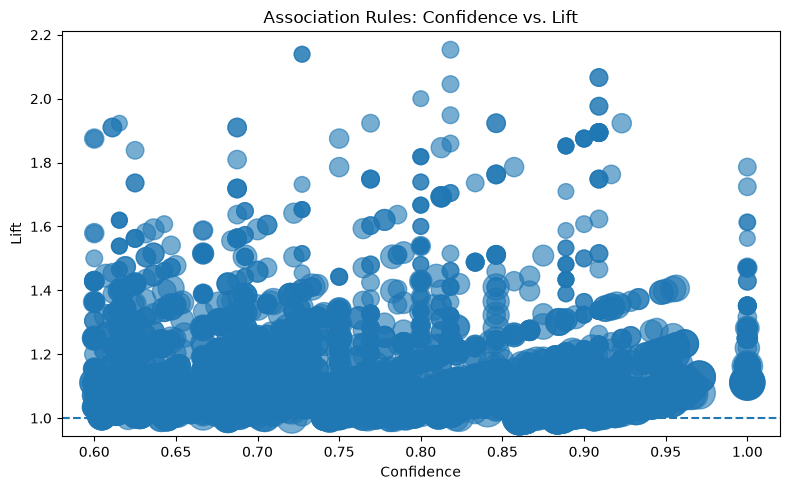

In [17]:
plot_rules = rules_distinct[
    (rules_distinct["support"] >= 0.10)
    & (rules_distinct["lift"] > 1.0)
].copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    plot_rules["confidence"],
    plot_rules["lift"],
    s=plot_rules["support"] * 800,
    alpha=0.6
)
plt.axhline(1, linestyle="--")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Association Rules: Confidence vs. Lift")
plt.tight_layout()
plt.show()

In [18]:
TARGET = "Q07_incorrect"

target_rules = rules_distinct[
    rules_distinct["consequents"].apply(lambda s: TARGET in s)
].copy()

target_rules = target_rules.sort_values(
    ["lift", "confidence"],
    ascending=False
)

target_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(15)

,antecedents,consequents,support,confidence,lift


In [19]:
export_rules = readable_rules.copy()
export_rules.to_csv("student_question_association_rules.csv", index=False)

print("Saved: student_question_association_rules.csv")

Saved: student_question_association_rules.csv
